# 💳 Credit Card Fraud Detection

## Project Overview

This project aims to detect fraudulent credit card transactions using Machine Learning algorithms. We will perform data analysis, preprocessing, model training, evaluation, and finally deploy the model using Streamlit.

---

**Author:** Prayag Sapariya

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Streamlit

In [25]:
# ==========================================
# Step 1 : Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [26]:
# ==========================================
# Step 2 : Load Dataset
# ==========================================

df = pd.read_csv("../data/creditcard.csv")

print(" Dataset Loaded Successfully")

 Dataset Loaded Successfully


#### Dataset Preview

In [27]:
# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 284807
Columns : 31


#### Column Names

In [29]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

#### Dataset Information

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### Observation

- Dataset contains 284,807 transactions.
- Total 31 columns are present.
- No missing values found.

#### Statistical Summary

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
...,...,...,...,...,...,...,...,...
V26,284807.0,1.686100e-15,0.482227,-2.604551,-0.326984,-0.052139,0.240952,3.517346
V27,284807.0,-3.661401e-16,0.403632,-22.565679,-0.070840,0.001342,0.091045,31.612198
V28,284807.0,-1.227452e-16,0.330083,-15.430084,-0.052960,0.011244,0.078280,33.847808
Amount,284807.0,8.834962e+01,250.120109,0.000000,5.600000,22.000000,77.165000,25691.160000


#### Check Missing Values

In [32]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
         ..
V26       0
V27       0
V28       0
Amount    0
Class     0
Length: 31, dtype: int64

#### Check Duplicate Rows

In [33]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 1081


## Exploratory Data Analysis (EDA)

#### Check Class Distribution

In [34]:
# Count normal and fraud transactions
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [37]:
class_percentage = df["Class"].value_counts(normalize=True) * 100
print(class_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


#### Bar Chart

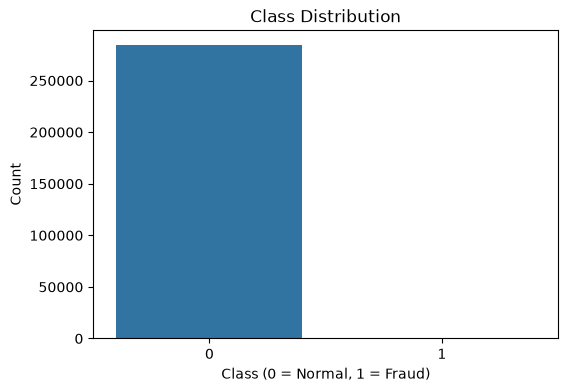

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")

plt.show()

#### Pie Chart

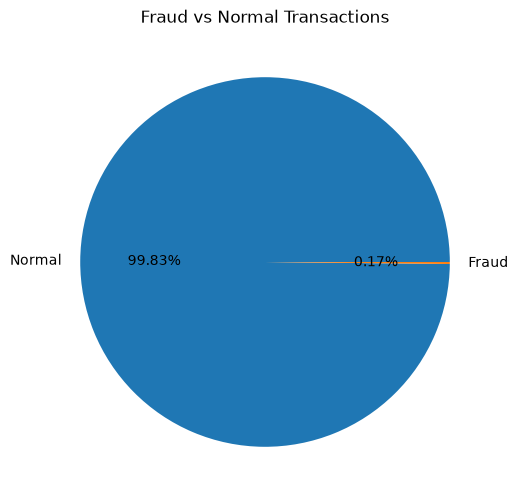

In [39]:
plt.figure(figsize=(6,6))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    labels=["Normal","Fraud"]
)

plt.title("Fraud vs Normal Transactions")

plt.ylabel("")

plt.show()

#### Amount Distribution

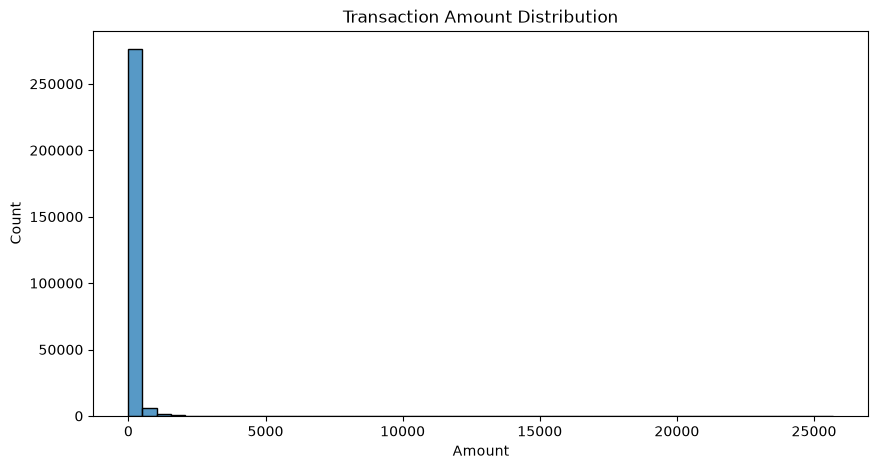

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

### Observation

- Most transaction amounts are small.
- A few transactions have very high values.

### Statistical Summary of Target

In [42]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


#### Correlation Matrix

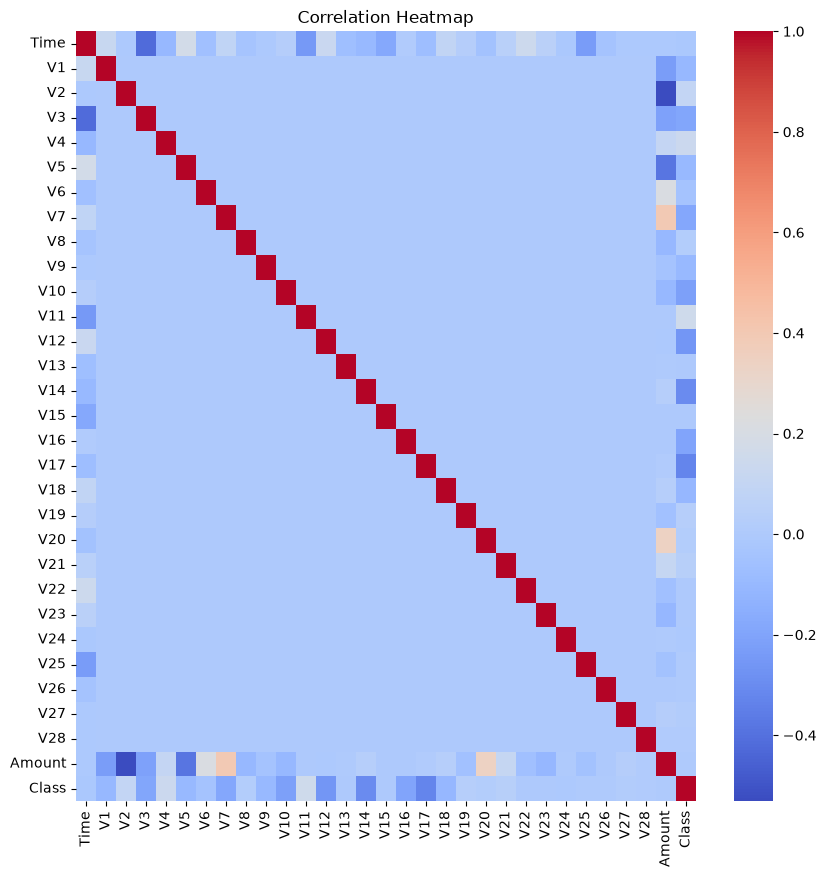

In [46]:
plt.figure(figsize=(10,10))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observations

- Dataset is highly imbalanced.
- Fraud transactions are very few.
- No missing values are present.
- Some features have strong positive/negative correlation with the target.
- Transaction amounts are mostly small.

## Data Preprocessing

### Feature Selection

In this step, we separate the input features (X) and the target variable (y).

In [48]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (284807, 30)
Target Shape : (284807,)


### Check Target Distribution

In [49]:
y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#### Observation

The dataset is highly imbalanced.
Most transactions belong to class 0 (Normal).
Very few belong to class 1 (Fraud).

### Why Class Imbalance Matters

Machine learning models may predict every transaction as Normal because the dataset contains very few fraud cases. This can result in high accuracy but poor fraud detection.

Therefore, we need to balance the dataset before training the model.

### Create Balanced Dataset (Undersampling)

In [50]:
# Separate classes
normal = df[df["Class"] == 0]
fraud = df[df["Class"] == 1]

print("Normal :", normal.shape)
print("Fraud :", fraud.shape)

Normal : (284315, 31)
Fraud : (492, 31)


Randomly sample normal transactions:

In [61]:
normal_sample = normal.sample(n=len(fraud), random_state=42)

balanced_df = pd.concat([normal_sample, fraud], axis=0)

balanced_df = balanced_df.sample(frac=1, random_state=42)

balanced_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
42756,41233.0,-10.645800,5.918307,-11.671043,8.807369,-7.975501,-3.586806,-13.616797,6.428169,-7.368451,-12.888158,6.854953,-13.211695,1.035612,-13.778956,1.040448,-11.290328,-20.578022,-7.547824,3.118480,-0.046170,2.571970,0.206809,-1.667801,0.558419,-0.027898,0.354254,0.273329,-0.152908,0.00,1
1686,1308.0,-1.379848,0.536720,2.647870,1.408111,0.126442,0.986525,0.960251,-0.629717,1.729173,1.346832,-0.622458,0.516210,0.174168,-2.023273,-1.185043,-2.036791,0.653358,-1.294348,1.297445,0.464675,-0.666874,-0.343574,0.022138,0.093532,0.011293,-0.503395,-0.438189,-0.346731,43.80,0
111690,72327.0,-4.198735,0.194121,-3.917586,3.920748,-1.875486,-2.118933,-3.614445,1.687884,-2.189871,-4.684233,4.376907,-5.007441,-1.304745,-6.192475,1.002404,-3.316934,-6.188834,-1.040413,1.233044,1.003350,0.801312,-0.183001,-0.440387,0.292539,-0.144967,-0.251744,1.249414,-0.131525,238.90,1
128360,78685.0,-0.671155,1.183971,0.793623,-0.218410,0.357282,-0.023707,0.363563,0.463983,-0.704518,-0.774565,-1.133336,-0.066681,0.275205,0.500851,0.965494,0.149958,-0.210491,-0.474939,0.032152,-0.161347,-0.083474,-0.352537,-0.092199,-0.764804,-0.292712,0.185362,-0.028254,0.055953,1.30,0
20746,31244.0,1.087002,0.065459,0.485043,1.343874,-0.283361,0.002520,-0.076665,0.165384,0.151865,0.065573,1.192505,0.810490,-1.145781,0.455426,-0.710613,-0.543406,0.138989,-0.438125,-0.152541,-0.223027,-0.040723,0.016005,-0.048042,0.208209,0.571482,-0.340377,0.028643,0.007649,18.56,0


Check class balance:

In [62]:
balanced_df["Class"].value_counts()

Class
1    492
0    492
Name: count, dtype: int64

#### Observation

The dataset is now balanced.
Both classes contain the same number of samples.

### New X and y

In [60]:
X = balanced_df.drop("Class", axis=1)

y = balanced_df["Class"]

print(X.shape)
print(y.shape)

(984, 30)
(984,)


#### Train-Test Split

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (787, 30)
Testing Data : (197, 30)


### Summary

- Selected input features and target.
- Balanced the dataset using undersampling.
- Split the data into training and testing sets.
- Prepared data for machine learning.

## Import Machine Learning Libraries

In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score,
 RocCurveDisplay)

#### Train Logistic Regression

In [72]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Model Trained Successfully")
log_model

Model Trained Successfully


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

#### Evaluate Logistic Regression

In [73]:
print("Accuracy :", accuracy_score(y_test, log_pred))
print("Precision :", precision_score(y_test, log_pred))
print("Recall :", recall_score(y_test, log_pred))
print("F1 Score :", f1_score(y_test, log_pred))

Accuracy : 0.934010152284264
Precision : 0.9473684210526315
Recall : 0.9183673469387755
F1 Score : 0.9326424870466321


#### Classification Report

In [74]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94        99
           1       0.95      0.92      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197



#### Confusion Matrix

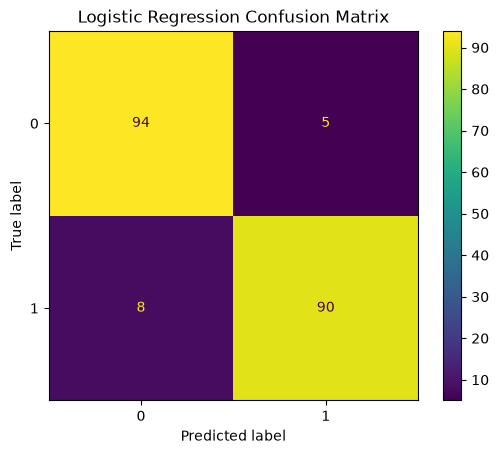

In [75]:
cm = confusion_matrix(y_test, log_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

#### ROC Curve

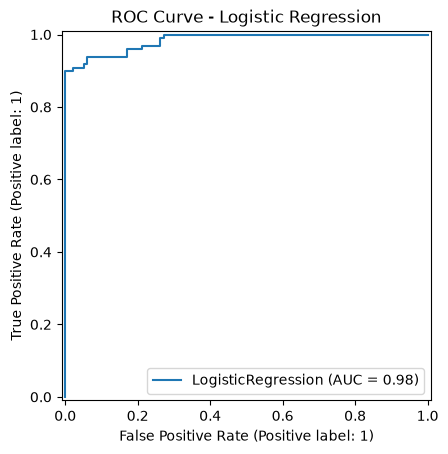

In [76]:
RocCurveDisplay.from_estimator(log_model, X_test, y_test)

plt.title("ROC Curve - Logistic Regression")

plt.show()

### Observation

The Logistic Regression model performs well on the balanced dataset and provides a good baseline for comparison with more complex models.

## Random Forest Classifier

In [77]:
rf_model = RandomForestClassifier( n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [78]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

Accuracy : 0.9441624365482234
Precision : 0.9578947368421052
Recall : 0.9285714285714286
F1 Score : 0.9430051813471503


In [79]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95        99
           1       0.96      0.93      0.94        98

    accuracy                           0.94       197
   macro avg       0.94      0.94      0.94       197
weighted avg       0.94      0.94      0.94       197



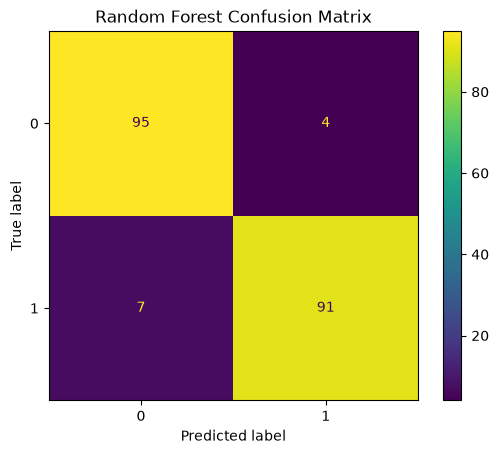

In [80]:
cm = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

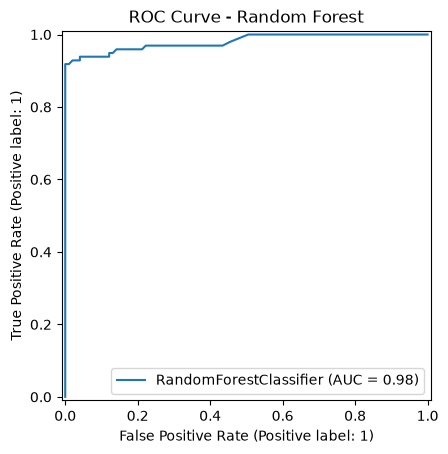

In [81]:
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)

plt.title("ROC Curve - Random Forest")

plt.show()

## Compare Models

In [82]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.934010,0.947368,0.918367,0.932642
1,Random Forest,0.944162,0.957895,0.928571,0.943005


## Final Observation

Random Forest achieved the best overall performance on the balanced dataset and was selected as the final model for deployment.

## Save the Best Model

In [84]:
import pickle
import os

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained Random Forest model
model_path = "../models/fraud_model.pkl"

with open(model_path, "wb") as file:
    pickle.dump(rf_model, file)

print("✅ Model saved successfully!")
print(f"Location: {model_path}")

✅ Model saved successfully!
Location: ../models/fraud_model.pkl


#### Load Model (Testing)

In [85]:
with open("../models/fraud_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


#### Test Loaded Model

In [86]:
prediction = loaded_model.predict(X_test[:5])

print("Predictions:")
print(prediction)

print("\nActual Values:")
print(y_test.iloc[:5].values)

Predictions:
[1 1 0 1 0]

Actual Values:
[1 1 0 1 0]


In [88]:
print(X.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='str')
